In [51]:
# use dfngp_env
import torch
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
# for reading HDF5 files
import h5py
import os

In [41]:
# import region bounds
from regions import ROSS_BOUNDS

# assign region bounds
x_min = ROSS_BOUNDS["x_min"]
x_max = ROSS_BOUNDS["x_max"]
y_min = ROSS_BOUNDS["y_min"]
y_max = ROSS_BOUNDS["y_max"]

# Reference basal mass balance map

- **Antarctic iceshelf melt rates**: Average basal melt rates for Antarctic ice shelves for the 2010–2018 period at high spatial resolution, estimated using CryoSat-2 data. This data file was last updated on 2020-06-11.


[](https://library.ucsd.edu/dc/object/bb0448974g)

Reference map: download to local with   
``wget https://library.ucsd.edu/dc/object/bb0448974g/_3_1.h5/download``

Other files:  
``wget https://library.ucsd.edu/dc/object/bb0448974g/_2_1.h5/download``

Reference:
- *Adusumilli, Susheel, et al. "Interannual variations in meltwater input to the Southern Ocean from Antarctic ice shelves." Nature geoscience 13.9 (2020): 616-620.* [Link to paper on Nature.](https://www.nature.com/articles/s41561-020-0616-z)

## ANT_iceshelf_melt_rates_CS2_2010-2018_v0.h5

Description:   
Average basal melt rates for Antarctic ice shelves for the 2010–2018 period at high spatial resolution, estimated using CryoSat-2 data. Interpolated values in regions with missing data are provided as a separate field. We are currently working on using ICESat-2 data to improve the estimates over regions with missing CryoSat-2 data.

Repository with preprocessing:  
https://github.com/sioglaciology/ice_shelf_change

## Units

| Field    | Description                                                                           |
| -------- | ------------------------------------------------------------------------------------- |
| `time`   | 2010–2018 average                                                               |
| `x`, `y` | Already in Antarctic Polar Stereographic Projection [EPSG:3031](https://epsg.io/3031) |
| `smb`    | **mm i.e. per year** (ice equivalent i.e., as stated in Fig. 1 in paper)                                                                  |

In [42]:
# Specify your local path to the HDF5 file
path_to_file = "/home/kim/data/adusumulli/ANT_iceshelf_melt_rates_CS2_2010-2018_v0.h5"

adusumulli_bmb = h5py.File(path_to_file,'r')

## Make tensor

In [43]:
# Read arrays
# (10941, 1)
x = np.array(adusumulli_bmb["/x"])
# (10229, 1)
y = np.array(adusumulli_bmb["/y"]) 
# (10229, 10941) (ny, nx)
# NOTE: negate to turn basal melt rate into bmb (sign convention flip)
bmb = - np.array(adusumulli_bmb["/w_b"])

# Convert to torch, squeezing dims
x_t = torch.as_tensor(x.squeeze(), dtype = torch.float32)
y_t = torch.as_tensor(y.squeeze(), dtype = torch.float32)
bmb_t = torch.as_tensor(bmb, dtype = torch.float32)

# Meshgrid that matches raster layout (ny, nx)
Y, X = torch.meshgrid(y_t, x_t, indexing = "ij")

# (3, ny, nx)
bmb_tensor = torch.stack([X, Y, bmb_t], dim = 0)

# Subset Ross region

In [44]:
# indices inside bounds
ix = torch.where((x_t >= x_min) & (x_t <= x_max))[0]
iy = torch.where((y_t >= y_min) & (y_t <= y_max))[0]
bmb_ross = bmb_tensor[:, iy[0] : iy[-1] + 1, ix[0] : ix[-1] + 1]

# Visualise data

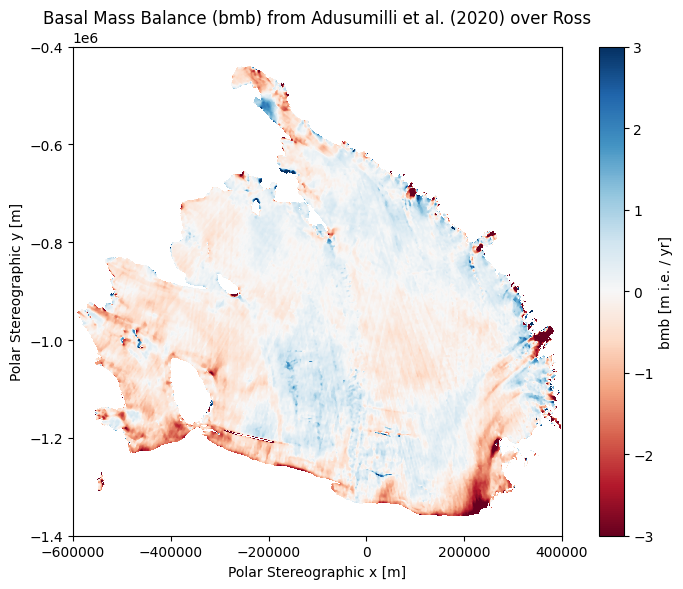

In [45]:
plt.figure(figsize = (8, 6))
pcm = plt.pcolormesh(
    bmb_ross[0],
    bmb_ross[1],
    bmb_ross[2], 
    cmap = "RdBu",
    vmax = 3.0,
    vmin = - 3.0
)
plt.colorbar(pcm, label = "bmb [m i.e. / yr]")
plt.title("Basal Mass Balance (bmb) from Adusumilli et al. (2020) over Ross")
plt.xlabel("Polar Stereographic x [m]")
plt.ylabel("Polar Stereographic y [m]")
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

# Interpolate at target grid

In [46]:
# Transform tensor to xarray DataArray for interpolation
x_np = x_t.detach().cpu().numpy()
y_np = y_t.detach().cpu().numpy()
bmb_np = bmb_t.detach().cpu().numpy()

bmb_da = xr.DataArray(
    bmb_np,
    dims = ("y", "x"),
    coords = {"x": x_np, "y": y_np},
    name = "bmb",
)

# Load target grid
target_grid_mask = xr.load_dataset("data/target_grid_mask.nc")

# Interpolate bmb onto the target grid's x/y
bmb_on_target = bmb_da.interp(
    x = target_grid_mask["x"],
    y = target_grid_mask["y"],
    method = "linear",
)

# Mask out values outside of the target region
bmb_on_target_masked = bmb_on_target.where(target_grid_mask["mask"] > 0)

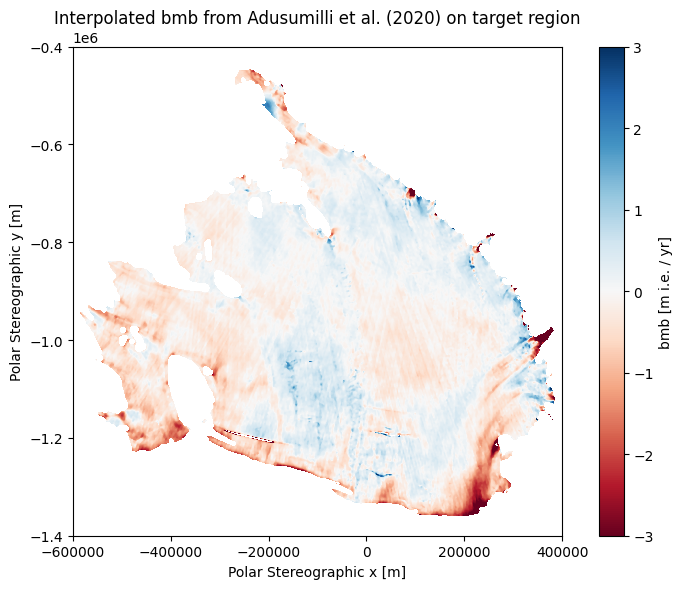

In [47]:
# Plot
plt.figure(figsize = (8, 6))
pcm = plt.pcolormesh(
    bmb_on_target_masked.x,
    bmb_on_target_masked.y,
    bmb_on_target_masked,
    cmap = "RdBu",
    vmin = -3.0,
    vmax = 3.0,
    shading = "auto"    
)

plt.colorbar(pcm, label = "bmb [m i.e. / yr]")
plt.title("Interpolated bmb from Adusumilli et al. (2020) on target region")
plt.xlabel("Polar Stereographic x [m]")
plt.ylabel("Polar Stereographic y [m]")
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

In [48]:
modis_ross = torch.load("data/modis/moa125_2014_hp1_v01_ross_with_grid_no_ocean.pt", weights_only = False)

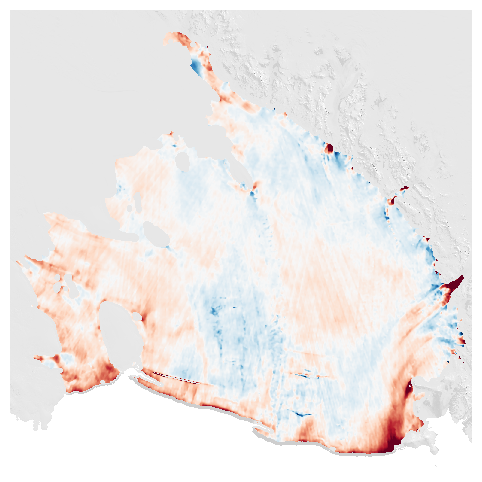

In [49]:
fig, ax = plt.subplots(figsize = (8, 6))

# 1) MODIS as background (draw first)
ax.pcolormesh(
    modis_ross[0],
    modis_ross[1], 
    modis_ross[2],
    cmap = "gray",
    # softer greys
    vmin = -30_000, 
    vmax = 30_000,
    # as less saturated background
    alpha = 0.4,
    zorder = 0,
)

# 2) SMB on top (draw second)
pcm = ax.pcolormesh(
    bmb_on_target_masked.x,
    bmb_on_target_masked.y,
    bmb_on_target_masked,
    cmap = "RdBu",
    vmin = -3.0,
    vmax = 3.0,
)

ax.set_aspect("equal")
ax.set_axis_off()

fig.savefig("figures/adusumilli_ross.png", dpi = 300, bbox_inches = "tight", pad_inches = 0)
plt.show()

# EXPORT

In [52]:
path = "data/fluxnet_div_ross.nc"

# 1) Open -> load into memory -> close file handle
with xr.open_dataset(path) as _ds:
    ds = _ds.load()

# 2) Add variable(s)
ds["adusumilli_bmb"] = (("y", "x"), bmb_on_target_masked.values)
ds["adusumilli_bmb"].attrs.update({
    "long_name": "Adusumilli basal mass balance on target grid",
    "units": "m yr-1",
})

# 3) Safe overwrite to SAME pathname (write temp, then atomic replace)
tmp_path = path + ".tmp"
ds.to_netcdf(tmp_path, mode = "w")
os.replace(tmp_path, path)

# TODO

- Export for comparison

# Thickness change data

## 1994 to 2018
- it_1 = 106 is labelled as thickness change since 1994 (last index)
- Altitery data is quarterly as far as i know

https://github.com/sioglaciology/ice_shelf_change/blob/master/read_height_change_file.ipynb

NOTE: for yearly, divide by 24

In [3]:
# Specify your local path to the HDF5 file
path_to_hc_file = "/home/kim/data/adusumulli/ANT_iceshelf_height_changes_RA_1994_2018_v0.h5"

adusumulli_height_change = h5py.File(path_to_hc_file,'r')

In [5]:
rho_ow = 1028
rho_ice = 917

print("Freeboard to thickness conversion factor:", (1 + rho_ice/ (rho_ow - rho_ice)))

Freeboard to thickness conversion factor: 9.26126126126126


In [ ]:
# Read arrays
# (436, 510)
x = np.array(adusumulli_height_change["/x"])
# (436, 510)
y = np.array(adusumulli_height_change["/y"]) 

# Freeboard change
# (107, 436, 510)
delta_h_altimetry = np.array(adusumulli_height_change['/h_alt'])
# (107, 436, 510)
delta_h_firn_correction = np.array(adusumulli_height_change['/h_firn'])

# Firn adjust and convert freeboard to thickness change (hydrostatic equilibrium)
# scales by ~ 9.26
# NOTE: appears to be change relative to 1994
thickness_change = (delta_h_altimetry - delta_h_firn_correction) * (1 + rho_ice/ (rho_ow - rho_ice))
# Assume this is thickness change over 24 years

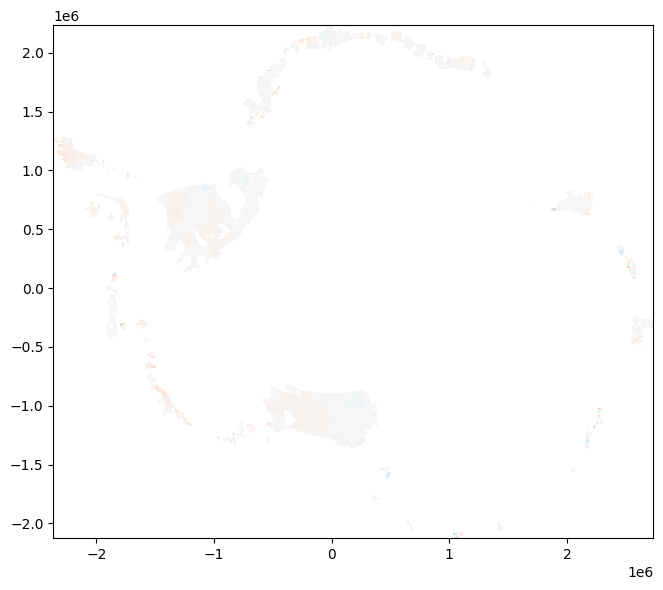

In [18]:
plt.figure(figsize = (8, 6))
pcm = plt.pcolormesh(
    x,
    y,
    thickness_change[10, :, :],  # convert from mm to m
    cmap = "RdBu",
    vmin = -50,
    vmax = 50,
    shading = "auto"    
)
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

# Interpolate to Ross

In [22]:
# 2D slice at time index 106
tc_106 = np.asarray(thickness_change[106, :, :])

# Ensure 1D x/y axes (works if x,y are already 1D; if they're 2D meshgrids, takes the axis vectors)
x1 = np.asarray(x).squeeze()
y1 = np.asarray(y).squeeze()
if x1.ndim == 2: x1 = x1[0, :]
if y1.ndim == 2: y1 = y1[:, 0]

# Wrap in xarray and interpolate onto target grid
thickness_change_da = xr.DataArray(
    tc_106,
    dims = ("y", "x"),
    coords = {"x": x1, "y": y1},
    name = "thickness_change",
)

target_grid_mask = xr.load_dataset("data/target_grid_mask.nc")

thickness_change_on_target = thickness_change_da.interp(
    x = target_grid_mask["x"],
    y = target_grid_mask["y"],
    method = "linear",
)

# Put into a Dataset and attach mask (same pattern as your SMB example)
thickness_change_on_target = thickness_change_on_target.to_dataset(name = "thickness_change")
thickness_change_on_target["mask"] = target_grid_mask["mask"]

In [23]:
thickness_change_on_target

<xarray.Dataset> Size: 36MB
Dimensions:           (x: 2000, y: 2000)
Coordinates:
  * x                 (x) float32 8kB -5.998e+05 -5.992e+05 ... 3.998e+05
  * y                 (y) float32 8kB -4.002e+05 -4.008e+05 ... -1.4e+06
Data variables:
    thickness_change  (y, x) float64 32MB nan nan nan nan ... nan nan nan nan
    mask              (y, x) int8 4MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0

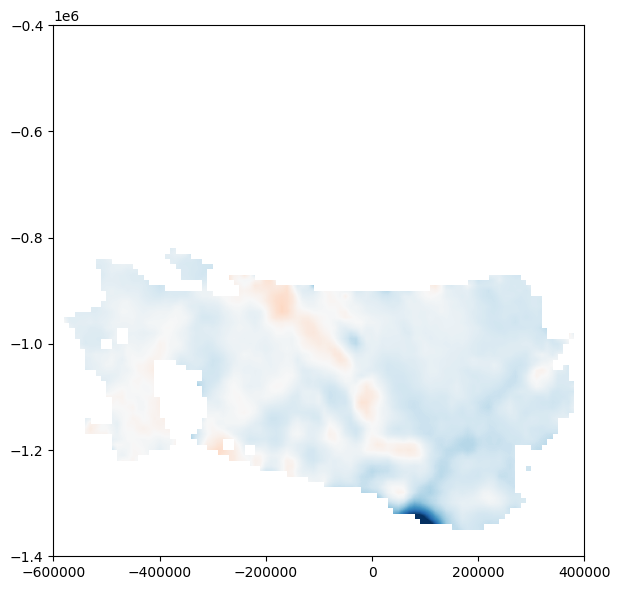

In [ ]:
# Plot
# NOTE: matches map: https://github.com/sioglaciology/ice_shelf_change/blob/master/read_height_change_file.ipynb
plt.figure(figsize = (8, 6))
pcm = plt.pcolormesh(
    thickness_change_on_target.x,
    thickness_change_on_target.y,
    thickness_change_on_target.thickness_change,  # convert to mean rate over 24 years
    cmap = "RdBu",
    vmin = -50,
    vmax = 50,
    shading = "auto"    
)
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()
# NOTE: Ross is growing (positive thickness change)

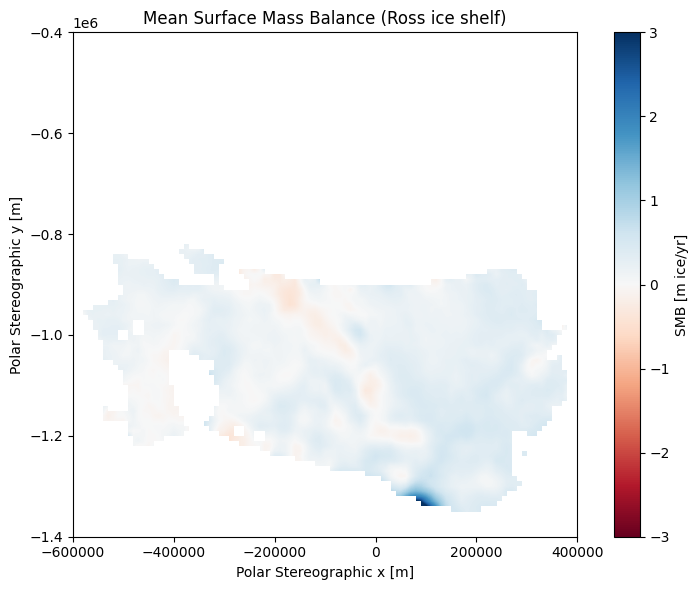

In [ ]:
# Plot
plt.figure(figsize = (8, 6))
pcm = plt.pcolormesh(
    thickness_change_on_target.x,
    thickness_change_on_target.y,
    thickness_change_on_target.thickness_change / 24,  # convert to mean rate over 24 years
    cmap = "RdBu",
    vmin = -3,
    vmax = 3,
    shading = "auto"    
)
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

In [27]:
modis_ross = torch.load("data/modis/moa125_2014_hp1_v01_ross_with_grid_no_ocean.pt", weights_only = False)

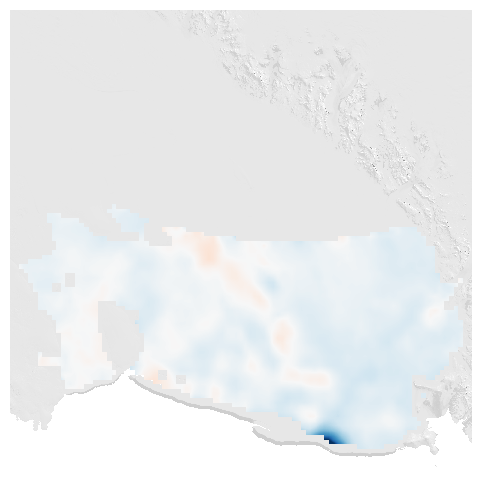

In [28]:
fig, ax = plt.subplots(figsize = (8, 6))

# 1) MODIS as background (draw first)
ax.pcolormesh(
    modis_ross[0],
    modis_ross[1], 
    modis_ross[2],
    cmap = "gray",
    # softer greys
    vmin = -30_000, 
    vmax = 30_000,
    # as less saturated background
    alpha = 0.4,
    zorder = 0,
)

# 2) SMB on top (draw second)
pcm = ax.pcolormesh(
    thickness_change_on_target.x,
    thickness_change_on_target.y,
    # dh/dt where t is a year
    thickness_change_on_target.thickness_change / 24,  # convert to mean rate over 24 years
    cmap = "RdBu",
    # fixed scale
    vmin = -3,
    vmax = 3,
    shading = "auto",
    alpha = 1.0,
    zorder = 1,
)

ax.set_aspect("equal")
ax.set_axis_off()

fig.savefig("figures/dhdt_adusumilli_ross.png", dpi = 300, bbox_inches = "tight", pad_inches = 0)
plt.show()

# Add to dataset

In [54]:
path = "data/fluxnet_div_ross.nc"

# 1) Open -> load into memory -> close file handle
with xr.open_dataset(path) as _ds:
    ds = _ds.load()

# 2) Add variable
ds["adusumilli_dhdt"] = (("y", "x"), thickness_change_on_target["thickness_change"].values / 24.0)
ds["adusumilli_dhdt"].attrs.update({
    "long_name": "Adusumilli thickness-change-derived dh/dt on target grid",
    "units": "m yr-1",
    "note": "Computed as thickness_change / 24",
})

# 3) Safe overwrite to SAME pathname (write temp, then atomic replace)
tmp_path = path + ".tmp"
ds.to_netcdf(tmp_path, mode = "w")
os.replace(tmp_path, path)